In [1]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets

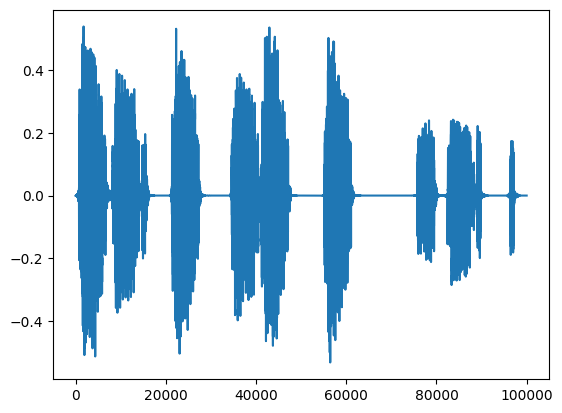

In [2]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/presets/Super Mario Bros. Theme Song.mp3'
audio = get_audio(audio_path)[:100000] # Quitar esto

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

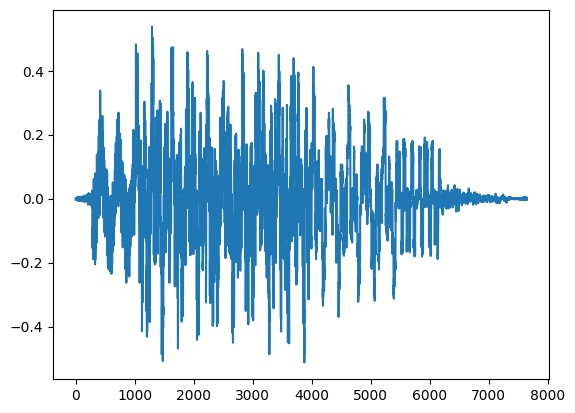

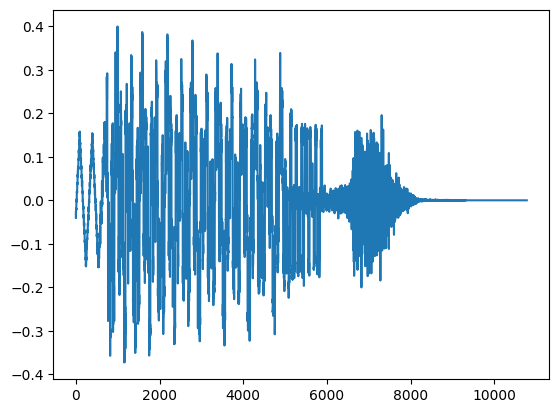

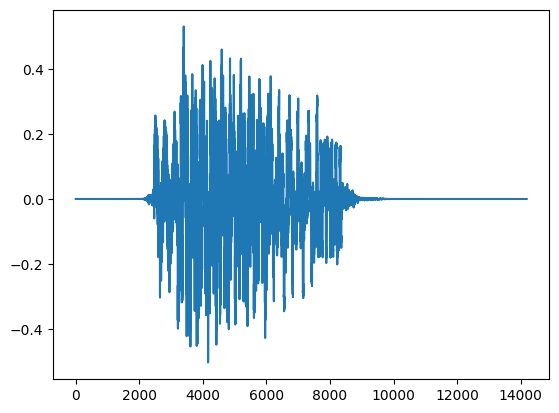

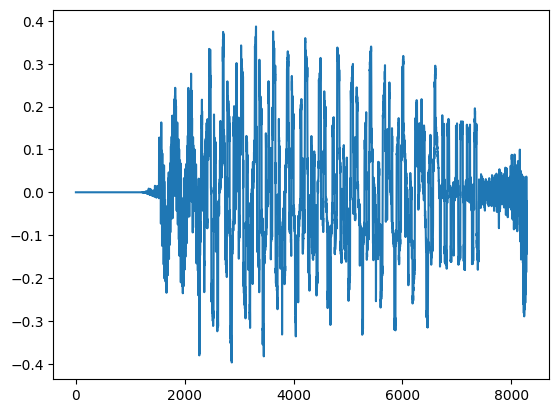

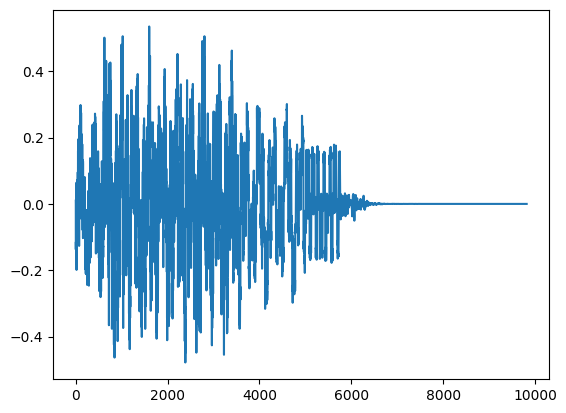

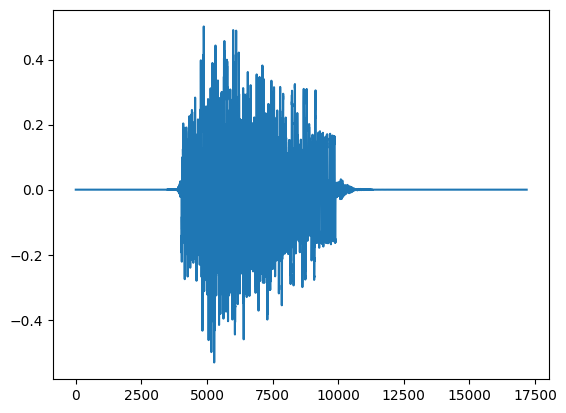

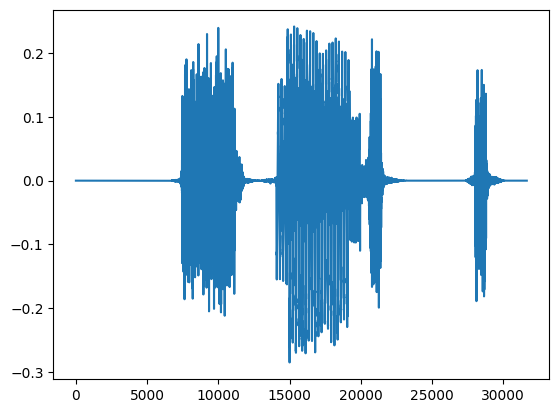

Pieces 7


In [3]:
audio_segments = split_audio(audio, prominence=0.06)

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [4]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best = search_with_DE(target_C, duration, disp=False, maxiter=200)
            best = search_with_CMA(target_C, duration, best)
        else:
            best = search_with_CMA(target_C, duration, last_best)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=362061, Wed Feb  4 18:19:29 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=371740, Wed Feb  4 18:19:51 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=427668, Wed Feb  4 18:20:48 2026)
Piece 2
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=391269, Wed Feb  4 18:22:10 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=342826, Wed Feb  4 18:23:39 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=277870, Wed Feb  4 18:24:40 2026)
Piece 3
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=297019, Wed Feb  4 18:25:23 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=340820, Wed Feb  4 18:27:42 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=421130, Wed Feb  4 18:29:42 2026)
Piece 4
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=357673, Wed Feb  4 18:31:45 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimens

In [5]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    # error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    # print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

{
  osc1_shape:   [
    1.6401506566187967
  ]
  osc1_phase:   [
    0.28033139012623687
  ]
  osc1_volume:   [
    0.024825791767557823
  ]
  osc1_freq:   [
    175.71925429353152
  ]
  osc2_shape:   [
    2.307794703543055
  ]
  osc2_phase:   [
    0.40117114699578277
  ]
  osc2_volume:   [
    0.30318934520331614
  ]
  osc2_freq:   [
    14918.729205350888
  ]
  osc3_shape:   [
    2.6788174039626926
  ]
  osc3_phase:   [
    0.19499411923689872
  ]
  osc3_volume:   [
    0.29646914980953415
  ]
  osc3_freq:   [
    369.86170290765784
  ]
  osc4_shape:   [
    2.3708051233947005
  ]
  osc4_phase:   [
    0.3359810997287319
  ]
  osc4_volume:   [
    0.6147235391837217
  ]
  osc4_freq:   [
    22.823545469125534
  ]
  oscnoise_volume:   [
    0.34241624769878265
  ]
  filter_envelope_attack:   [
    0.2656668777264824
  ]
  filter_envelope_decay:   [
    0.5087106149824783
  ]
  filter_envelope_sustain:   [
    0.7759970192091132
  ]
  filter_envelope_release:   [
    0.0542367192114

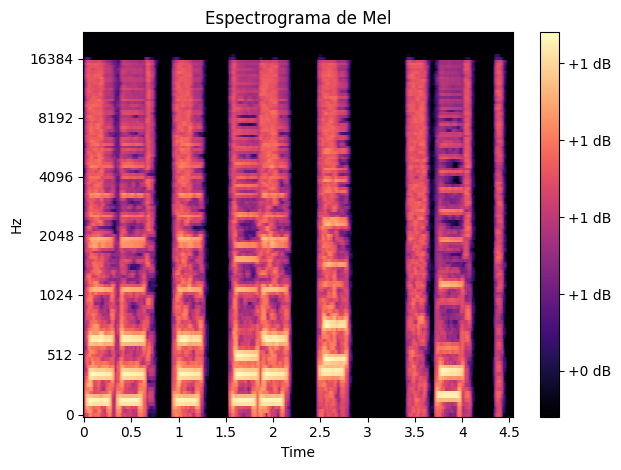

In [6]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

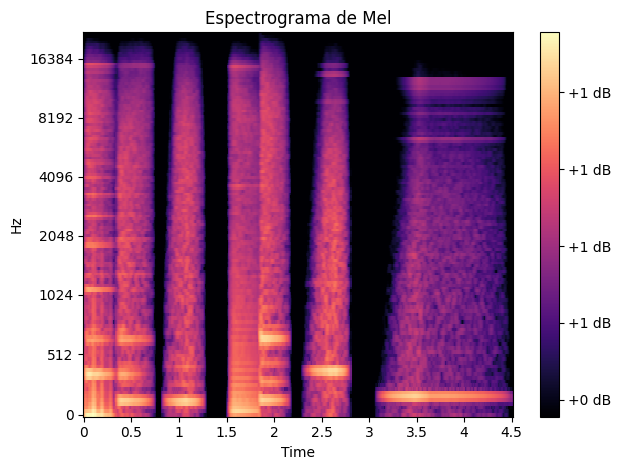

In [7]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))